# Training Prep For The Upgraded DDPM

This notebook converts the upgraded aligned dataset into train / validation / test tensors for the next retraining run.

## What it does

- reads the aligned market + macro dataset
- identifies target columns and dynamic conditioning columns
- scales targets and conditioning features using train-only statistics
- applies chronological train / val / test splits
- builds rolling windows for the diffusion model
- saves arrays, metadata tables, and scaler payloads

The structure intentionally mirrors the earlier project notebook so we can compare the upgraded retrain against the original DDPM as cleanly as possible.

In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "IPython": "IPython",
}

missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All required packages are already available.")

All required packages are already available.


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Configuration

This notebook expects the aligned dataset to have been produced already by:

1. `release_aware_macro_loader.ipynb`
2. `market_state_and_alignment_builder.ipynb`

In [3]:
SPEC_PATH = Path("dataset_spec_v1.json")
ARTIFACT_ROOT = Path.cwd() / "counterfactual_data_build"

with open(SPEC_PATH, "r", encoding="utf-8") as handle:
    dataset_spec = json.load(handle)

aligned_path = ARTIFACT_ROOT / Path(dataset_spec["loader_outputs"]["aligned_dataset_csv"])
windows_dir = ARTIFACT_ROOT / "processed" / "windows"
tables_dir = ARTIFACT_ROOT / "outputs" / "tables"

windows_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

if not aligned_path.exists():
    raise FileNotFoundError(
        f"Missing aligned dataset: {aligned_path}. Run the market-state alignment notebook first."
    )

seq_len = int(dataset_spec["training_layout"]["seq_len"])
forecast_horizon = int(dataset_spec["training_layout"]["forecast_horizon"])
split_ratios = dataset_spec["training_layout"]["split_ratios"]

print("Aligned dataset:", aligned_path)
print("Windows dir:", windows_dir)
print("Tables dir:", tables_dir)
print("Sequence length:", seq_len)
print("Forecast horizon:", forecast_horizon)

Aligned dataset: C:\Users\sammy\finance-ui\counterfactual_data_build\processed\aligned\aligned_counterfactual_dataset_v1.csv
Windows dir: C:\Users\sammy\finance-ui\counterfactual_data_build\processed\windows
Tables dir: C:\Users\sammy\finance-ui\counterfactual_data_build\outputs\tables
Sequence length: 30
Forecast horizon: 30


## Load And Inspect The Aligned Dataset

In [4]:
aligned_df = pd.read_csv(aligned_path)
aligned_df["Date"] = pd.to_datetime(aligned_df["Date"]).dt.normalize()
aligned_df = aligned_df.sort_values("Date").reset_index(drop=True)

target_cols = [target["target_column"] for target in dataset_spec["targets"]]
dynamic_condition_cols = [
    column
    for column in aligned_df.columns
    if column not in {"Date", *target_cols}
]

required_cols = ["Date"] + target_cols + dynamic_condition_cols
aligned_df = aligned_df[required_cols].dropna().reset_index(drop=True)

print("Aligned shape:", aligned_df.shape)
print("Target columns:", target_cols)
print("Condition column count:", len(dynamic_condition_cols))
display(aligned_df.tail())

Aligned shape: (3921, 94)
Target columns: ['SPY_log_return', 'QQQ_log_return', 'GC_log_return', 'CL_log_return', 'ZN_log_return']
Condition column count: 88


,Date,SPY_log_return,QQQ_log_return,GC_log_return,CL_log_return,ZN_log_return,SPY_price,SPY_return_5d,SPY_return_20d,SPY_realized_vol_5d,SPY_realized_vol_20d,SPY_downside_semivol_20d,SPY_max_drawdown_20d,SPY_rolling_skew_20d,SPY_rolling_kurtosis_20d,SPY_volume,SPY_volume_shock_20d,QQQ_price,QQQ_return_5d,QQQ_return_20d,QQQ_realized_vol_5d,QQQ_realized_vol_20d,QQQ_downside_semivol_20d,QQQ_max_drawdown_20d,QQQ_rolling_skew_20d,QQQ_rolling_kurtosis_20d,QQQ_volume,QQQ_volume_shock_20d,GC_price,GC_return_5d,GC_return_20d,GC_realized_vol_5d,GC_realized_vol_20d,GC_downside_semivol_20d,GC_max_drawdown_20d,GC_rolling_skew_20d,GC_rolling_kurtosis_20d,CL_price,CL_return_5d,CL_return_20d,CL_realized_vol_5d,CL_realized_vol_20d,CL_downside_semivol_20d,CL_max_drawdown_20d,CL_rolling_skew_20d,CL_rolling_kurtosis_20d,ZN_price,ZN_return_5d,ZN_return_20d,ZN_realized_vol_5d,ZN_realized_vol_20d,ZN_downside_semivol_20d,ZN_max_drawdown_20d,ZN_rolling_skew_20d,ZN_rolling_kurtosis_20d,gold_minus_equity_return_5d,oil_minus_equity_return_5d,growth_minus_broad_equity_return_5d,rates_minus_equity_return_5d,cross_asset_corr_20d,equity_realized_vol_20d,commodity_realized_vol_20d,rates_realized_vol_20d,FEDFUNDS_level,FEDFUNDS_delta,FEDFUNDS_z,DGS2_level,DGS2_delta,DGS2_z,DGS10_level,DGS10_delta,DGS10_z,T10Y2Y_level,T10Y2Y_delta,T10Y2Y_z,CPIAUCSL_level,CPIAUCSL_delta,CPIAUCSL_z,UNRATE_level,UNRATE_delta,UNRATE_z,PAYEMS_level,PAYEMS_delta,PAYEMS_z,INDPRO_level,INDPRO_delta,INDPRO_z,VIXCLS_level,VIXCLS_delta,VIXCLS_z,release_day_flag,days_since_cpi,days_since_fomc,days_since_nfp
3916,2026-04-23,-0.0039,-0.0056,-0.0058,0.0306,-0.0021,708.4500,0.0096,0.0757,0.1208,0.1785,0.1581,-0.0203,0.1899,0.7116,"56,174,000.0000",-0.5321,651.4200,0.0170,0.1027,0.1495,0.2203,0.2138,-0.0270,-0.0745,0.3220,"40,099,800.0000",-0.7034,"4,705.1001",-0.0169,0.0336,0.2109,0.2823,0.2928,-0.0328,-0.4698,-0.0215,95.8500,0.0122,0.0594,1.0276,1.0112,1.5088,-0.2576,-1.4356,2.5934,111.0469,-0.0015,0.0014,0.0419,0.0430,0.0391,-0.0060,0.0156,1.0373,-0.0266,0.0025,0.0073,-0.0112,0.1469,0.1994,0.6467,0.0430,3.6400,0.0000,-1.4223,3.7900,0.0100,0.6832,4.3000,0.0000,0.5121,0.5100,-0.0100,-0.7011,330.2930,0.0000,2.4099,4.3000,0.0000,-0.1088,"158,466.0000",0.0000,-2.1055,101.7898,0.0000,-1.4519,18.9200,-0.5800,0.0925,1,13,22,20
3917,2026-04-24,0.0077,0.0189,0.0036,-0.0152,0.0015,713.9400,0.0053,0.1014,0.1047,0.1602,0.1246,-0.0085,0.3958,1.2285,"45,182,000.0000",-0.8401,663.8800,0.0229,0.1458,0.1718,0.1974,0.1595,-0.0076,0.1097,0.2177,"45,563,100.0000",-0.3337,"4,722.2998",-0.0282,0.0763,0.1694,0.2402,0.2200,-0.0328,-0.1672,-0.2948,94.4000,0.1185,-0.0008,0.4274,1.0010,1.3999,-0.2576,-1.3417,2.5065,111.2188,-0.0045,0.0095,0.0261,0.0360,0.0248,-0.0060,0.7820,0.3073,-0.0336,0.1132,0.0176,-0.0098,0.0661,0.1788,0.6206,0.0360,3.6400,0.0000,-1.4098,3.8300,0.0400,0.9128,4.3400,0.0400,0.8081,0.5100,0.0000,-0.6961,330.2930,0.0000,2.3782,4.3000,0.0000,-0.1129,"158,466.0000",0.0000,-2.0786,101.7898,0.0000,-1.4389,19.3100,0.3900,0.2178,1,14,23,21
3918,2026-04-27,0.0017,0.0005,-0.0100,0.0207,-0.0017,715.1700,0.0091,0.1203,0.1019,0.1390,0.0610,-0.0085,1.1407,1.4552,"33,135,900.0000",-1.1591,664.2300,0.0266,0.1661,0.1649,0.1735,0.0853,-0.0070,0.6657,-0.0300,"32,717,000.0000",-0.9872,"4,675.3999",-0.0277,0.0400,0.1686,0.2300,0.2140,-0.0375,-0.0303,-0.1451,96.3700,0.0727,-0.0334,0.2645,0.9855,1.3999,-0.2576,-1.3533,2.6876,111.0312,-0.0056,0.0079,0.0264,0.0367,0.0262,-0.0062,0.8021,0.1827,-0.0367,0.0637,0.0175,-0.0147,0.1289,0.1562,0.6077,0.0367,3.6400,0.0000,-1.3974,3.8300,0.0000,0.9105,4.3400,0.0000,0.8071,0.5100,0.0000,-0.6932,330.2930,0.0000,2.3475,4.3000,0.0000,-0.1171,"158,466.0000",0.0000,-2.0526,101.7898,0.0000,-1.4260,19.3100,0.0000,0.2285,0,17,26,24
3919,2026-04-28,-0.0049,-0.0101,-0.0181,0.0363,-0.0015,711.6900,0.0108,0.1188,0.0952,0.1404,0.0660,-0.0085,1.0983,1.3734,"43,066,700.0000",-0.7140,657.5500,0.0203,0.1637,0.1860,0.1765,0.1000,-0.0101,0.5826,-0.0207,"34,041,200.0000",-0.8195,"4,591.5000",-0.0230,0.01

## Chronological Split

We keep the same chronological split logic as the original notebook:

- train first
- validation next
- test last

In [5]:
n_total = len(aligned_df)
n_train = int(n_total * float(split_ratios["train"]))
n_val = int(n_total * float(split_ratios["val"]))
n_test = n_total - n_train - n_val

train_df = aligned_df.iloc[:n_train].copy().reset_index(drop=True)
val_df = aligned_df.iloc[n_train:n_train + n_val].copy().reset_index(drop=True)
test_df = aligned_df.iloc[n_train + n_val:].copy().reset_index(drop=True)

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "row_count": len(train_df),
            "start_date": str(train_df["Date"].min().date()),
            "end_date": str(train_df["Date"].max().date()),
        },
        {
            "split": "val",
            "row_count": len(val_df),
            "start_date": str(val_df["Date"].min().date()),
            "end_date": str(val_df["Date"].max().date()),
        },
        {
            "split": "test",
            "row_count": len(test_df),
            "start_date": str(test_df["Date"].min().date()),
            "end_date": str(test_df["Date"].max().date()),
        },
    ]
)

display(split_summary)

,split,row_count,start_date,end_date
0,train,2744,2010-06-07,2021-05-28
1,val,588,2021-06-01,2023-09-29
2,test,589,2023-10-02,2026-04-29


## Scale Targets And Dynamic Conditioning Features

Train-only scaling keeps the future splits honest.

In [6]:
target_scaler = StandardScaler()
condition_scaler = StandardScaler()

target_scaler.fit(train_df[target_cols])
condition_scaler.fit(train_df[dynamic_condition_cols])

def apply_scaling(frame):
    out = frame.copy()
    out[target_cols] = target_scaler.transform(out[target_cols])
    out[dynamic_condition_cols] = condition_scaler.transform(out[dynamic_condition_cols])
    return out

train_scaled = apply_scaling(train_df)
val_scaled = apply_scaling(val_df)
test_scaled = apply_scaling(test_df)

scaler_payload = {
    "target_cols": target_cols,
    "condition_cols": dynamic_condition_cols,
    "return_scaler_mean": target_scaler.mean_.tolist(),
    "return_scaler_scale": target_scaler.scale_.tolist(),
    "condition_scaler_mean": condition_scaler.mean_.tolist(),
    "condition_scaler_scale": condition_scaler.scale_.tolist(),
    "seq_len": seq_len,
    "forecast_horizon": forecast_horizon,
}

scaling_check_rows = []
for split_name, frame in [
    ("train_scaled", train_scaled),
    ("val_scaled", val_scaled),
    ("test_scaled", test_scaled),
]:
    for column in target_cols[:3] + dynamic_condition_cols[:10]:
        scaling_check_rows.append(
            {
                "split": split_name,
                "column": column,
                "mean": float(frame[column].mean()),
                "std": float(frame[column].std(ddof=0)),
            }
        )

scaling_check = pd.DataFrame(scaling_check_rows)
display(scaling_check.head(20))

,split,column,mean,std
0,train_scaled,SPY_log_return,-0.0000,1.0000
1,train_scaled,QQQ_log_return,-0.0000,1.0000
2,train_scaled,GC_log_return,0.0000,1.0000
3,train_scaled,SPY_price,0.0000,1.0000
4,train_scaled,SPY_return_5d,-0.0000,1.0000
5,train_scaled,SPY_return_20d,0.0000,1.0000
6,train_scaled,SPY_realized_vol_5d,-0.0000,1.0000
7,train_scaled,SPY_realized_vol_20d,0.0000,1.0000
8,train_scaled,SPY_downside_semivol_20d,0.0000,1.0000
9,train_scaled,SPY_max_drawdown_20d,0.0000,1.0000


## Build Rolling Windows

This mirrors the original pipeline structure:

- `X`: scaled target history
- `C`: scaled dynamic conditioning history
- `meta`: end-date metadata for each sample

In [7]:
def build_windows(split_df, split_name, seq_len, target_cols, condition_cols):
    x_windows = []
    c_windows = []
    end_dates = []

    target_values = split_df[target_cols].to_numpy(dtype=np.float32)
    condition_values = split_df[condition_cols].to_numpy(dtype=np.float32)
    dates = split_df["Date"].to_numpy()

    for end_idx in range(seq_len - 1, len(split_df)):
        start_idx = end_idx - seq_len + 1
        x_window = target_values[start_idx:end_idx + 1]
        c_window = condition_values[start_idx:end_idx + 1]

        if x_window.shape != (seq_len, len(target_cols)):
            continue
        if c_window.shape != (seq_len, len(condition_cols)):
            continue

        x_windows.append(x_window)
        c_windows.append(c_window)
        end_dates.append(pd.Timestamp(dates[end_idx]))

    if not x_windows:
        raise RuntimeError(f"No windows were created for split {split_name}")

    X = np.stack(x_windows).astype(np.float32)
    C = np.stack(c_windows).astype(np.float32)
    meta = pd.DataFrame(
        {
            "split": split_name,
            "window_end_date": end_dates,
        }
    )
    return X, C, meta


X_train, C_train, meta_train = build_windows(train_scaled, "train", seq_len, target_cols, dynamic_condition_cols)
X_val, C_val, meta_val = build_windows(val_scaled, "val", seq_len, target_cols, dynamic_condition_cols)
X_test, C_test, meta_test = build_windows(test_scaled, "test", seq_len, target_cols, dynamic_condition_cols)

window_shapes = pd.DataFrame(
    [
        {"array_name": "X_train", "shape": str(X_train.shape)},
        {"array_name": "C_train", "shape": str(C_train.shape)},
        {"array_name": "X_val", "shape": str(X_val.shape)},
        {"array_name": "C_val", "shape": str(C_val.shape)},
        {"array_name": "X_test", "shape": str(X_test.shape)},
        {"array_name": "C_test", "shape": str(C_test.shape)},
    ]
)

display(window_shapes)

,array_name,shape
0,X_train,"(2715, 30, 5)"
1,C_train,"(2715, 30, 88)"
2,X_val,"(559, 30, 5)"
3,C_val,"(559, 30, 88)"
4,X_test,"(560, 30, 5)"
5,C_test,"(560, 30, 88)"


## Save Arrays, Metadata, And Scalers

In [8]:
np.save(windows_dir / "X_train.npy", X_train)
np.save(windows_dir / "C_train.npy", C_train)
np.save(windows_dir / "X_val.npy", X_val)
np.save(windows_dir / "C_val.npy", C_val)
np.save(windows_dir / "X_test.npy", X_test)
np.save(windows_dir / "C_test.npy", C_test)

meta_train.to_csv(windows_dir / "meta_train.csv", index=False)
meta_val.to_csv(windows_dir / "meta_val.csv", index=False)
meta_test.to_csv(windows_dir / "meta_test.csv", index=False)

with open(windows_dir / "scalers.json", "w", encoding="utf-8") as handle:
    json.dump(scaler_payload, handle, indent=2)

split_summary.to_csv(tables_dir / "time_split_summary.csv", index=False)
window_shapes.to_csv(tables_dir / "window_array_shapes.csv", index=False)
scaling_check.to_csv(tables_dir / "scaling_check_summary.csv", index=False)

print("Saved arrays and metadata to:", windows_dir)
print("Saved summaries to:", tables_dir)

Saved arrays and metadata to: C:\Users\sammy\finance-ui\counterfactual_data_build\processed\windows
Saved summaries to: C:\Users\sammy\finance-ui\counterfactual_data_build\outputs\tables


## Diagnostics

These plots help verify that the upgraded target set is stable enough before retraining.

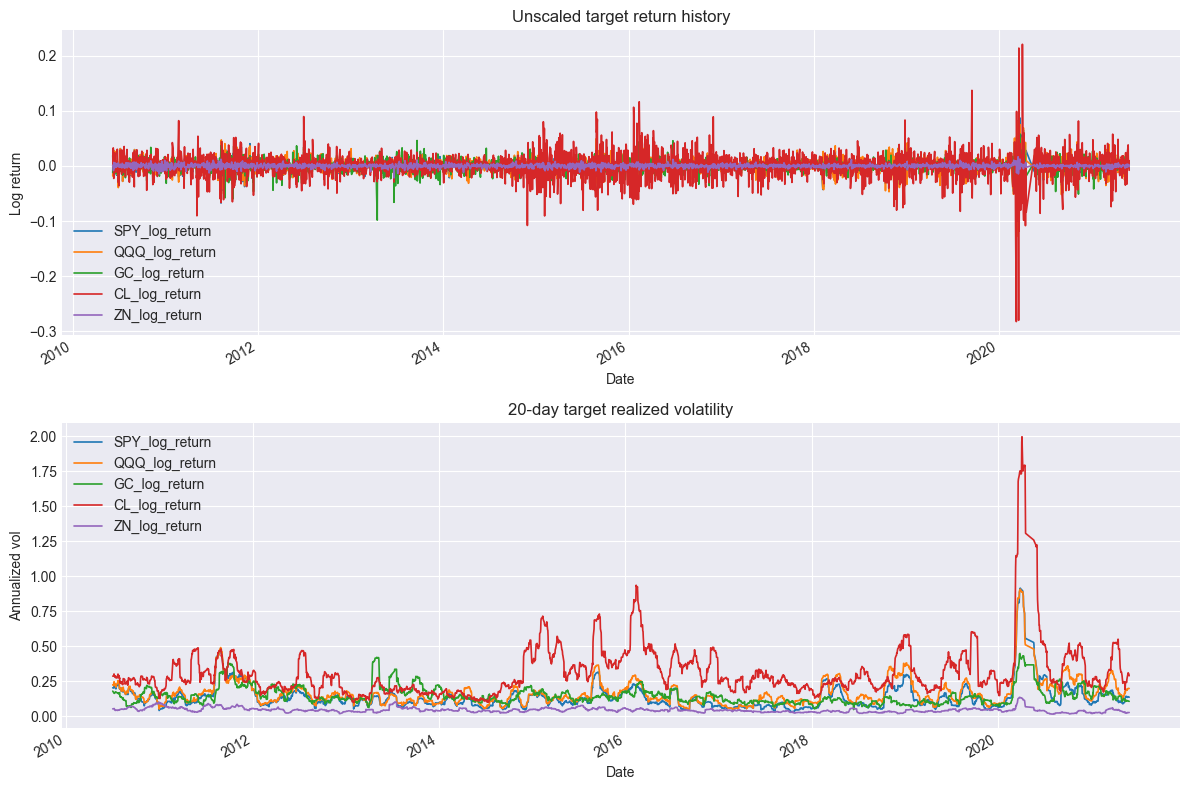

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

train_df.plot(x="Date", y=target_cols, ax=axes[0], linewidth=1.2)
axes[0].set_title("Unscaled target return history")
axes[0].set_ylabel("Log return")

rolling_target_vol = train_df[target_cols].rolling(20).std(ddof=0) * np.sqrt(252)
rolling_target_vol["Date"] = train_df["Date"]
rolling_target_vol.plot(x="Date", y=target_cols, ax=axes[1], linewidth=1.2)
axes[1].set_title("20-day target realized volatility")
axes[1].set_ylabel("Annualized vol")

plt.tight_layout()
plt.show()

## Output Summary

In [10]:
print("Training prep complete.")
print()
print("Target columns:")
for col in target_cols:
    print("-", col)
print()
print("Condition column count:", len(dynamic_condition_cols))
print("First 15 condition columns:")
for col in dynamic_condition_cols[:15]:
    print("-", col)
print()
print("Window shapes:")
print(window_shapes.to_string(index=False))

Training prep complete.

Target columns:
- SPY_log_return
- QQQ_log_return
- GC_log_return
- CL_log_return
- ZN_log_return

Condition column count: 88
First 15 condition columns:
- SPY_price
- SPY_return_5d
- SPY_return_20d
- SPY_realized_vol_5d
- SPY_realized_vol_20d
- SPY_downside_semivol_20d
- SPY_max_drawdown_20d
- SPY_rolling_skew_20d
- SPY_rolling_kurtosis_20d
- SPY_volume
- SPY_volume_shock_20d
- QQQ_price
- QQQ_return_5d
- QQQ_return_20d
- QQQ_realized_vol_5d

Window shapes:
array_name          shape
   X_train  (2715, 30, 5)
   C_train (2715, 30, 88)
     X_val   (559, 30, 5)
     C_val  (559, 30, 88)
    X_test   (560, 30, 5)
    C_test  (560, 30, 88)
